<a href="https://colab.research.google.com/github/Deyv0R/repo1/blob/main/%D0%9A%D0%B8%D1%8F%D0%BD%D0%B8%D1%86%D1%8F_%D0%9A%D1%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Розмір: (995, 28)

Пропуски:
 rank                                         0
Youtuber                                     0
subscribers                                  0
video views                                  0
category                                    46
Title                                        0
uploads                                      0
Country                                    122
Abbreviation                               122
channel_type                                30
video_views_rank                             1
country_rank                               116
channel_type_rank                           33
video_views_for_the_last_30_days            56
lowest_monthly_earnings                      0
highest_monthly_earnings                     0
lowest_yearly_earnings                       0
highest_yearly_earnings                      0
subscribers_for_last_30_days               337
created_year                                 5
created_month                 

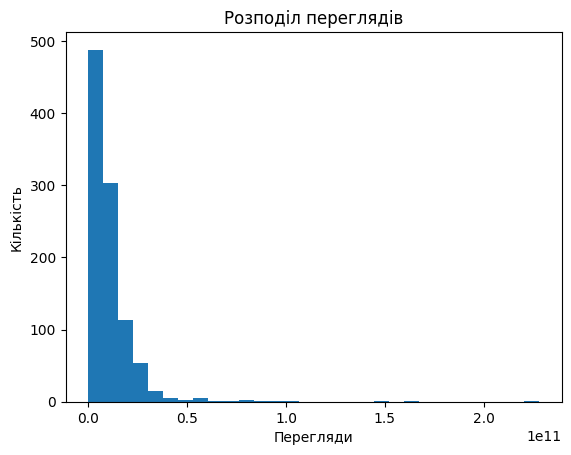

Максимум: 228000000000.0
Мінімум: 0.0
Середнє: 11039537052.03819
Країна з найбільшою кількістю відео:
India
Найбільше uploads: ABP NEWS
Найменше uploads: Music


In [10]:
import pandas as pd
# 1–2. Завантаження CSV + перші 5 рядків
df = pd.read_csv('/content/drive/MyDrive/КСВД/Global YouTube Statistics.csv', encoding='latin-1')
df.head()

# 3. Розмір, пропуски, дублікати
# Розміри датасету
print("Розмір:", df.shape)

# Пропуски
print("\nПропуски:\n", df.isnull().sum())

# Дублікати
print("\nКількість дублікатів:", df.duplicated().sum())

# 4. Заповнення пропусків
# Заповнюємо тільки числові стовпці
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        df[col] = df[col].astype(float)
        df[col] = df[col].fillna(df[col].mean())

# 5. Повторна перевірка пропусків
print("Пропуски після обробки:\n", df.isnull().sum())

# 6. Кількість унікальних країн
print("Кількість країн:", df['Country'].nunique())

# 7. Гістограма переглядів
import matplotlib.pyplot as plt

# заміни 'video views' якщо інша назва
df['video views'].plot(kind='hist', bins=30)

plt.title("Розподіл переглядів")
plt.xlabel("Перегляди")
plt.ylabel("Кількість")
plt.show()

# 8. max / min / mean
print("Максимум:", df['video views'].max())
print("Мінімум:", df['video views'].min())
print("Середнє:", df['video views'].mean())

# 9. Країна з найбільшою кількістю відео
country_uploads = df.groupby('Country')['uploads'].sum()

print("Країна з найбільшою кількістю відео:")
print(country_uploads.idxmax())

# 10. Відео з max / min uploads
# максимальні uploads
max_video = df.loc[df['uploads'].idxmax()]
print("Найбільше uploads:", max_video['Title'])

# мінімальні uploads
min_video = df.loc[df['uploads'].idxmin()]
print("Найменше uploads:", min_video['Title'])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
0            1   55   Male         Blouse  Clothing                     53   
1            2   19   Male        Sweater  Clothing                     64   
2            3   50   Male          Jeans  Clothing                     73   
3            4   21   Male        Sandals  Footwear                     90   
4            5   45   Male         Blouse  Clothing                     49   

        Location Size      Color  Season  Review Rating Subscription Status  \
0       Kentucky    L       Gray  Winter            3.1                 Yes   
1          Maine    L     Maroon  Winter            3.1                 Yes   
2  Massachusetts    S     Maroon  Spring            3.1                 Yes   
3   Rhode Island    M     Maroon  Spring            3.5                 Yes   
4      

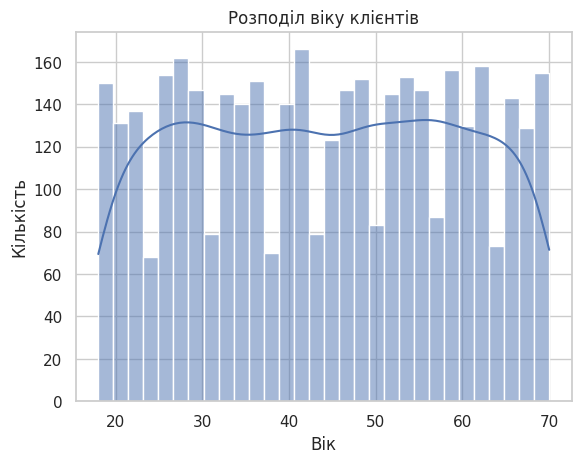

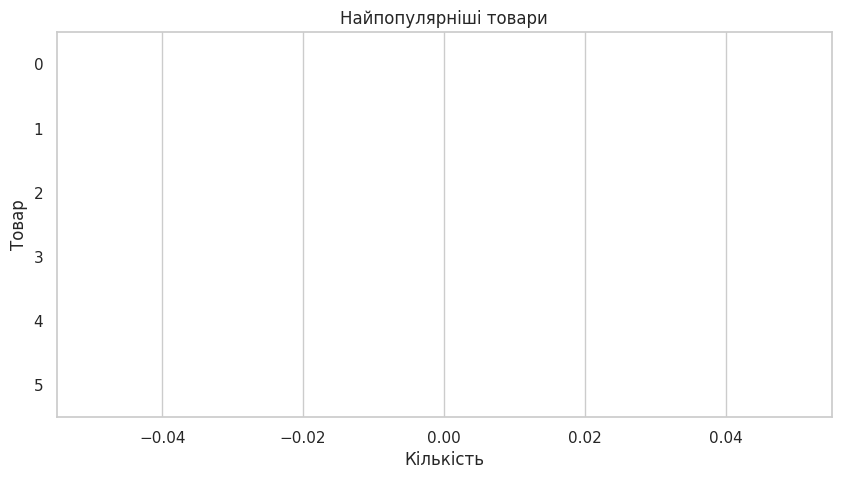

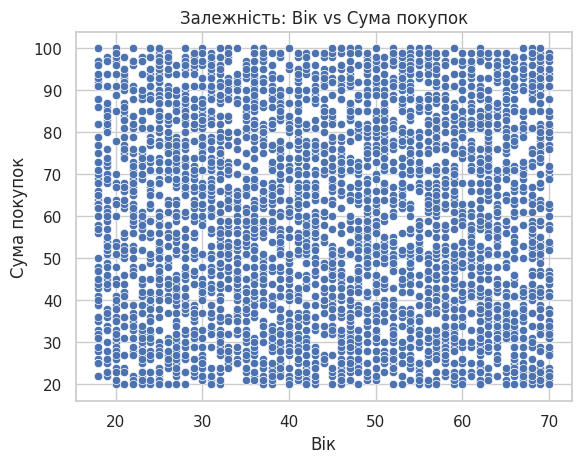

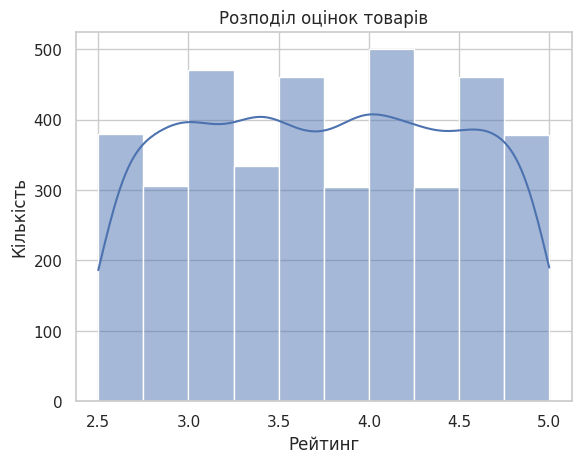

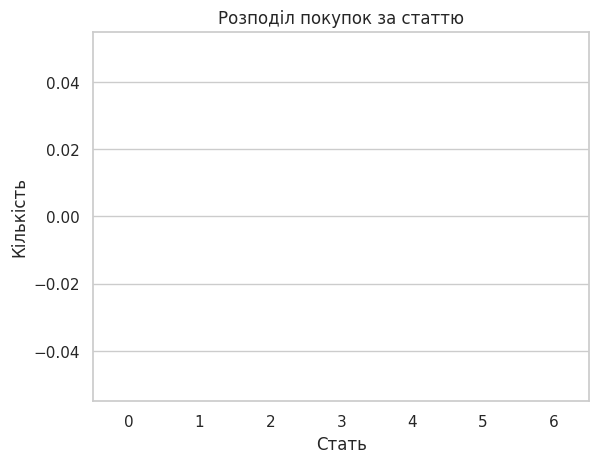

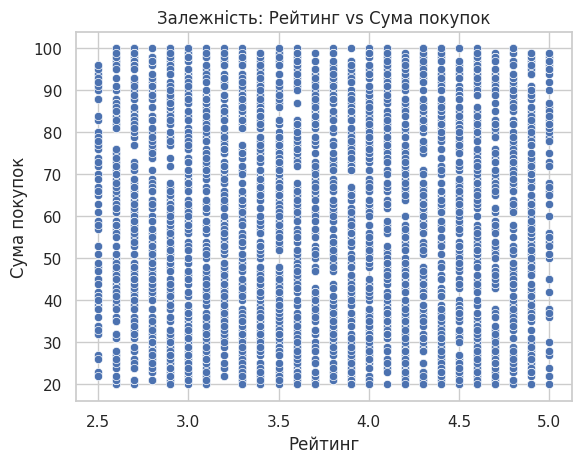

In [18]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import zipfile
import seaborn as sns
import matplotlib.pyplot as plt


# Шлях до архіву
zip_path = '/content/drive/MyDrive/КСВД/archive.zip'


# Розпакування архіву
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/data')


# Завантаження CSV
csv_path = '/content/data/shopping_trends.csv'
df = pd.read_csv(csv_path)


# Перегляд перших рядків
print(df.head())


# Перевірка датасету
print("\nРозмір:", df.shape)
print("\nПропуски:\n", df.isnull().sum())
print("\nТипи даних:\n", df.dtypes)


# Перейменування колонок
df.columns = df.columns.str.lower().str.replace(' ', '_')


# Обробка числових даних (щоб не було помилок)
for col in df.columns:
    try:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].fillna(df[col].mean())
    except:
        pass
# Перейменування (щоб теж не було помилок)
df.rename(columns={
    'purchase_amount_(usd)': 'purchase_amount',
    'review_rating': 'review_rating'
}, inplace=True)

# Налаштування стилю графіків
sns.set(style="whitegrid")

# 1. Гістограма віку
plt.figure()
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Розподіл віку клієнтів")
plt.xlabel("Вік")
plt.ylabel("Кількість")
plt.show()


# 2. Популярність товарів
plt.figure(figsize=(10,5))
sns.countplot(y=df['item_purchased'], order=df['item_purchased'].value_counts().index)
plt.title("Найпопулярніші товари")
plt.xlabel("Кількість")
plt.ylabel("Товар")
plt.show()


# 3. Вік vs Сума покупок
plt.figure()
sns.scatterplot(x='age', y='purchase_amount', data=df)
plt.title("Залежність: Вік vs Сума покупок")
plt.xlabel("Вік")
plt.ylabel("Сума покупок")
plt.show()


# 4. Розподіл рейтингів
plt.figure()
sns.histplot(df['review_rating'], bins=10, kde=True)
plt.title("Розподіл оцінок товарів")
plt.xlabel("Рейтинг")
plt.ylabel("Кількість")
plt.show()


# 5. Розподіл за статтю
plt.figure()
sns.countplot(x='gender', data=df)
plt.title("Розподіл покупок за статтю")
plt.xlabel("Стать")
plt.ylabel("Кількість")
plt.show()


# 6. Рейтинг vs Сума покупок
plt.figure()
sns.scatterplot(x='review_rating', y='purchase_amount', data=df)
plt.title("Залежність: Рейтинг vs Сума покупок")
plt.xlabel("Рейтинг")
plt.ylabel("Сума покупок")
plt.show()

In [21]:
import pandas as pd
import altair as alt
import plotly.express as px
from vega_datasets import data
from IPython.display import display

# Включення Altair у Colab
alt.data_transformers.disable_max_rows()


# 1. Горизонтальна діаграма (врожайність пшениці)
wheat = data.wheat()

# Основна діаграма
bars = alt.Chart(wheat).mark_bar().encode(
    x='wheat:Q',
    y=alt.Y('year:O', sort='-x'),
)

# Текстові мітки
text = bars.mark_text(
    align='left',
    dx=3
).encode(
    text='wheat:Q'
)

chart1 = (bars + text).properties(
    title="Врожайність пшениці по роках"
)

chart1


# 2. Багатошарова діаграма (електроенергія Айова)
iowa = data.iowa_electricity()

chart2 = alt.Chart(iowa).mark_area(opacity=0.7).encode(
    x='year:T',
    y='net_generation:Q',
    color='source:N'
).properties(
    title="Виробництво електроенергії в Айові"
)

chart2


# 3. Plotly scatter (Iris dataset)
iris = px.data.iris()

fig = px.scatter(
    iris,
    x='sepal_width',
    y='sepal_length',
    size='petal_length',
    color='species',
    hover_data=['petal_width'],
    title="Iris Dataset: Scatter Plot"
)

display(chart1)
display(chart2)
fig.show()

alt.LayerChart(...)

alt.Chart(...)